# 04 — Inteligência Computacional I: Predição de Churn

**Etapa 04 — Construção do Modelo Inteligente**  
**Dataset:** Telco Customer Churn  
**Problema:** Classificação binária supervisionada — prever se um cliente vai cancelar o serviço (`Churn = Yes`)

---

## Estrutura do Notebook

| Seção | Conteúdo |
|---|---|
| 1 | Definição da tarefa de Inteligência Computacional |
| 2 | Escolha justificada da técnica |
| 3 | Preparação dos dados para o modelo |
| 4 | Construção do modelo inicial |
| 5 | Treinamento e avaliação preliminar |
| 6 | Comparação com e sem uso dos clusters |

---
## 1 · Definição da Tarefa de Inteligência Computacional

### 1.1 Problema de negócio

Uma operadora de telecomunicações perde receita recorrente toda vez que um cliente cancela o serviço (churn). O custo de aquisição de um novo cliente é significativamente maior que o custo de retenção. Portanto, **identificar com antecedência quais clientes têm maior probabilidade de cancelar** é estrategicamente valioso.

### 1.2 Formulação como tarefa de IC

| Atributo | Valor |
|---|---|
| **Tipo de tarefa** | Aprendizado supervisionado — classificação binária |
| **Variável-alvo** | `Churn` → 0 (Não cancela) / 1 (Cancela) |
| **Instâncias** | 7.043 clientes |
| **Distribuição de classes** | ~73,5% Não / ~26,5% Sim (desbalanceado) |
| **Entradas disponíveis** | Dados demográficos, contratuais, de consumo e clusters não supervisionados |

### 1.3 Hipótese central

> A incorporação do **cluster K-Means** (gerado de forma não supervisionada na Fase 2) como atributo preditivo adicional deve melhorar o desempenho do modelo, pois os clusters capturam padrões comportamentais que não estão explicitamente representados nas features originais.

---
## 2 · Escolha Justificada da Técnica

### 2.1 Técnicas selecionadas

| Modelo | Papel | Justificativa |
|---|---|---|
| **Logistic Regression** | Baseline linear | Simples, interpretável, coeficientes revelam importância de atributos; referência mínima |
| **Decision Tree** | Baseline interpretável | Regras de decisão explícitas; fácil de comunicar a stakeholders de negócio |
| **Random Forest** | Modelo principal | Ensemble robusto; mitiga overfitting; estima importância de atributos; lida bem com dados mistos e desbalanceamento |
| **MLP (Rede Neural)** | Modelo avançado | Captura relações não lineares complexas; complementa o ensemble |

### 2.2 Justificativa para Random Forest como modelo principal

1. **Robustez ao desbalanceamento**: suporte nativo a `class_weight='balanced'`
2. **Importância de atributos**: mede o ganho de informação de cada feature, incluindo `cluster`
3. **Sem exigência de normalização**: diferente de MLP e Logistic Regression, não requer escalonamento
4. **Baixa sensibilidade a outliers**: mediana das árvores suaviza o efeito de valores extremos
5. **Desempenho empírico**: Random Forests consistentemente superam baselines em benchmarks de churn

### 2.3 Tratamento do desbalanceamento

Com 73,5% vs 26,5%, um classificador ingênuo atingiria ~73,5% de accuracy sempre predizendo "Não cancela". Estratégias adotadas:
- `class_weight='balanced'` nos modelos que suportam
- **SMOTE** (*Synthetic Minority Over-sampling Technique*) aplicado **apenas ao conjunto de treino**
- Métrica primária: **F1-Score** e **ROC-AUC** em vez de accuracy

---
## 3 · Preparação dos Dados para o Modelo

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/mrrobot/development/whoiamrootuser/churn-prediction-and-retention


### 3.1 Carga dos dados e reconstrução dos clusters K-Means

In [2]:
# Carrega base limpa
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "telco_clean.csv")
print(f"Base limpa carregada: {df.shape}")
print(f"Distribuição Churn:\n{df['Churn'].value_counts()}")

Base limpa carregada: (7043, 35)
Distribuição Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [3]:
# Reconstrói os clusters K-Means usando o modelo e scaler salvos na Fase 2
scaler_cluster = joblib.load(PROJECT_ROOT / "models" / "scaler.joblib")
kmeans = joblib.load(PROJECT_ROOT / "models" / "kmeans_model.joblib")

# Replica o mesmo pré-processamento feito em 02_clustering.ipynb
df_enc = df.copy()

contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
binary_map = {"Yes": 1, "No": 0, "No internet service": -1}

df_enc["Contract_enc"] = df_enc["Contract"].map(contract_map)
df_enc["TechSupport_enc"] = df_enc["TechSupport"].map(binary_map)
df_enc["OnlineSecurity_enc"] = df_enc["OnlineSecurity"].map(binary_map)

df_enc = pd.get_dummies(
    df_enc,
    columns=["InternetService", "PaymentMethod"],
    drop_first=False,
)

df_enc[["tenure_scaled", "MonthlyCharges_scaled"]] = scaler_cluster.transform(
    df_enc[["tenure", "MonthlyCharges"]]
)

# Seleciona as mesmas features usadas no K-Means (colunas resultantes do encoding)
exclude_cols = {
    "customerID", "Churn", "Churn_label", "tenure", "MonthlyCharges",
    "Contract", "TechSupport", "OnlineSecurity",
    # colunas originais da telco_clean que não fazem parte das features de cluster
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "OnlineBackup", "DeviceProtection", "StreamingTV",
    "StreamingMovies", "PaperlessBilling", "TotalCharges",
    "gender_label", "Contract_ordinal", "Partner_binary", "Dependents_binary",
    "PhoneService_binary", "PaperlessBilling_binary", "MultipleLines_binary",
    "OnlineSecurity_binary", "OnlineBackup_binary", "DeviceProtection_binary",
    "TechSupport_binary", "StreamingTV_binary", "StreamingMovies_binary",
}

feature_cols_cluster = [c for c in df_enc.columns if c not in exclude_cols]
print(f"Features para reconstrução dos clusters ({len(feature_cols_cluster)}):")
print(feature_cols_cluster)

X_cluster = df_enc[feature_cols_cluster].values
df["kmeans_cluster"] = kmeans.predict(X_cluster)

cluster_labels_map = {0: "Insatisfeito com serviços", 1: "Econômico estável"}
df["kmeans_label"] = df["kmeans_cluster"].map(cluster_labels_map)

print(f"\nDistribuição dos clusters K-Means:\n{df['kmeans_cluster'].value_counts()}")
print(f"\nChurn por cluster:")
print(df.groupby("kmeans_cluster")["Churn"].value_counts(normalize=True).unstack())

Features para reconstrução dos clusters (12):
['Contract_enc', 'TechSupport_enc', 'OnlineSecurity_enc', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_scaled', 'MonthlyCharges_scaled']

Distribuição dos clusters K-Means:
kmeans_cluster
0    5486
1    1557
Name: count, dtype: int64

Churn por cluster:
Churn                 No       Yes
kmeans_cluster                    
0               0.681918  0.318082
1               0.920360  0.079640


### 3.2 Engenharia de features para predição

In [4]:
# Constrói a base de features para predição
# Usa as colunas já encodadas da telco_clean.csv + OHE para colunas categóricas restantes

# Colunas a descartar (identificadores, alvo, duplicatas de encoding)
DROP_COLS = [
    "customerID",
    "gender",         # já em gender_label
    "Partner",        # já em Partner_binary
    "Dependents",     # já em Dependents_binary
    "PhoneService",   # já em PhoneService_binary
    "MultipleLines",  # já em MultipleLines_binary
    "OnlineSecurity", # já em OnlineSecurity_binary
    "OnlineBackup",   # já em OnlineBackup_binary
    "DeviceProtection",# já em DeviceProtection_binary
    "TechSupport",    # já em TechSupport_binary
    "StreamingTV",    # já em StreamingTV_binary
    "StreamingMovies",# já em StreamingMovies_binary
    "PaperlessBilling",# já em PaperlessBilling_binary
    "Contract",       # já em Contract_ordinal
    "Churn",          # alvo
    "Churn_label",    # alvo codificado
    "kmeans_label",   # rótulo textual do cluster
]

# OHE para InternetService e PaymentMethod (categóricas ainda brutas)
df_pred = pd.get_dummies(
    df.drop(columns=DROP_COLS),
    columns=["InternetService", "PaymentMethod"],
    drop_first=True,
)

# Converte booleanos para int
bool_cols = df_pred.select_dtypes(include="bool").columns
df_pred[bool_cols] = df_pred[bool_cols].astype(int)

y = df["Churn_label"].values  # 0 = No, 1 = Yes

# X_sem: sem features de cluster
X_sem = df_pred.drop(columns=["kmeans_cluster"]).values
feature_names_sem = df_pred.drop(columns=["kmeans_cluster"]).columns.tolist()

# X_com: com feature de cluster
X_com = df_pred.values
feature_names_com = df_pred.columns.tolist()

print(f"Features SEM cluster: {X_sem.shape[1]}")
print(f"Features COM cluster: {X_com.shape[1]}")
print(f"Instâncias: {len(y)} | Positivos (churn): {y.sum()} ({y.mean():.1%})")

Features SEM cluster: 22
Features COM cluster: 23
Instâncias: 7043 | Positivos (churn): 1869 (26.5%)


### 3.3 Divisão treino/teste e aplicação de SMOTE

In [5]:
# Divisão estratificada 80/20
X_sem_train, X_sem_test, y_train, y_test = train_test_split(
    X_sem, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_com_train, X_com_test, _, _ = train_test_split(
    X_com, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_sem_train.shape[0]} | Teste: {X_sem_test.shape[0]}")
print(f"Churn no treino: {y_train.mean():.1%} | Churn no teste: {y_test.mean():.1%}")

# Aplica SMOTE apenas no conjunto de TREINO
smote = SMOTE(random_state=RANDOM_STATE)
X_sem_train_res, y_train_res = smote.fit_resample(X_sem_train, y_train)
X_com_train_res, _ = smote.fit_resample(X_com_train, y_train)

print(f"\nApós SMOTE:")
print(f"  Treino SEM cluster: {X_sem_train_res.shape[0]} | Churn: {y_train_res.mean():.1%}")
print(f"  Treino COM cluster: {X_com_train_res.shape[0]}")

Treino: 5634 | Teste: 1409
Churn no treino: 26.5% | Churn no teste: 26.5%

Após SMOTE:
  Treino SEM cluster: 8278 | Churn: 50.0%
  Treino COM cluster: 8278


---
## 4 · Construção do Modelo Inicial

São instanciados 4 modelos na versão **sem ajuste de hiperparâmetros** (modelos iniciais). O objetivo desta etapa é estabelecer a linha de base de desempenho antes de qualquer otimização.

In [6]:
# Instanciação dos modelos iniciais (sem tuning)
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
}

print("Modelos instanciados:")
for name, model in models.items():
    print(f"  [{name}] {model.__class__.__name__}")

Modelos instanciados:
  [Logistic Regression] LogisticRegression
  [Decision Tree] DecisionTreeClassifier
  [Random Forest] RandomForestClassifier
  [MLP] MLPClassifier


---
## 5 · Treinamento e Avaliação Preliminar

### 5.1 Treinamento nos dados com SMOTE (SEM cluster)

In [7]:
# MLP requer normalização
scaler_mlp = StandardScaler()
X_sem_train_scaled = scaler_mlp.fit_transform(X_sem_train_res)
X_sem_test_scaled = scaler_mlp.transform(X_sem_test)

results_sem = {}

for name, model in models.items():
    X_tr = X_sem_train_scaled if name == "MLP" else X_sem_train_res
    X_te = X_sem_test_scaled  if name == "MLP" else X_sem_test

    model.fit(X_tr, y_train_res)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results_sem[name] = {
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "y_pred": y_pred,
        "y_prob": y_prob,
    }
    print(f"{name:25s} | F1={results_sem[name]['f1']:.4f} | AUC={results_sem[name]['auc']:.4f}")

Logistic Regression       | F1=0.6122 | AUC=0.8400
Decision Tree             | F1=0.5828 | AUC=0.8088
Random Forest             | F1=0.5764 | AUC=0.8242
MLP                       | F1=0.5909 | AUC=0.8231


### 5.2 Relatório de classificação — Random Forest (modelo principal)

In [8]:
rf_pred = results_sem["Random Forest"]["y_pred"]
print("Classification Report — Random Forest (SEM cluster)")
print(classification_report(y_test, rf_pred, target_names=["Não Cancela (0)", "Cancela (1)"]))

Classification Report — Random Forest (SEM cluster)
                 precision    recall  f1-score   support

Não Cancela (0)       0.84      0.88      0.86      1035
    Cancela (1)       0.62      0.53      0.58       374

       accuracy                           0.79      1409
      macro avg       0.73      0.71      0.72      1409
   weighted avg       0.78      0.79      0.79      1409



### 5.3 Matrizes de confusão — todos os modelos

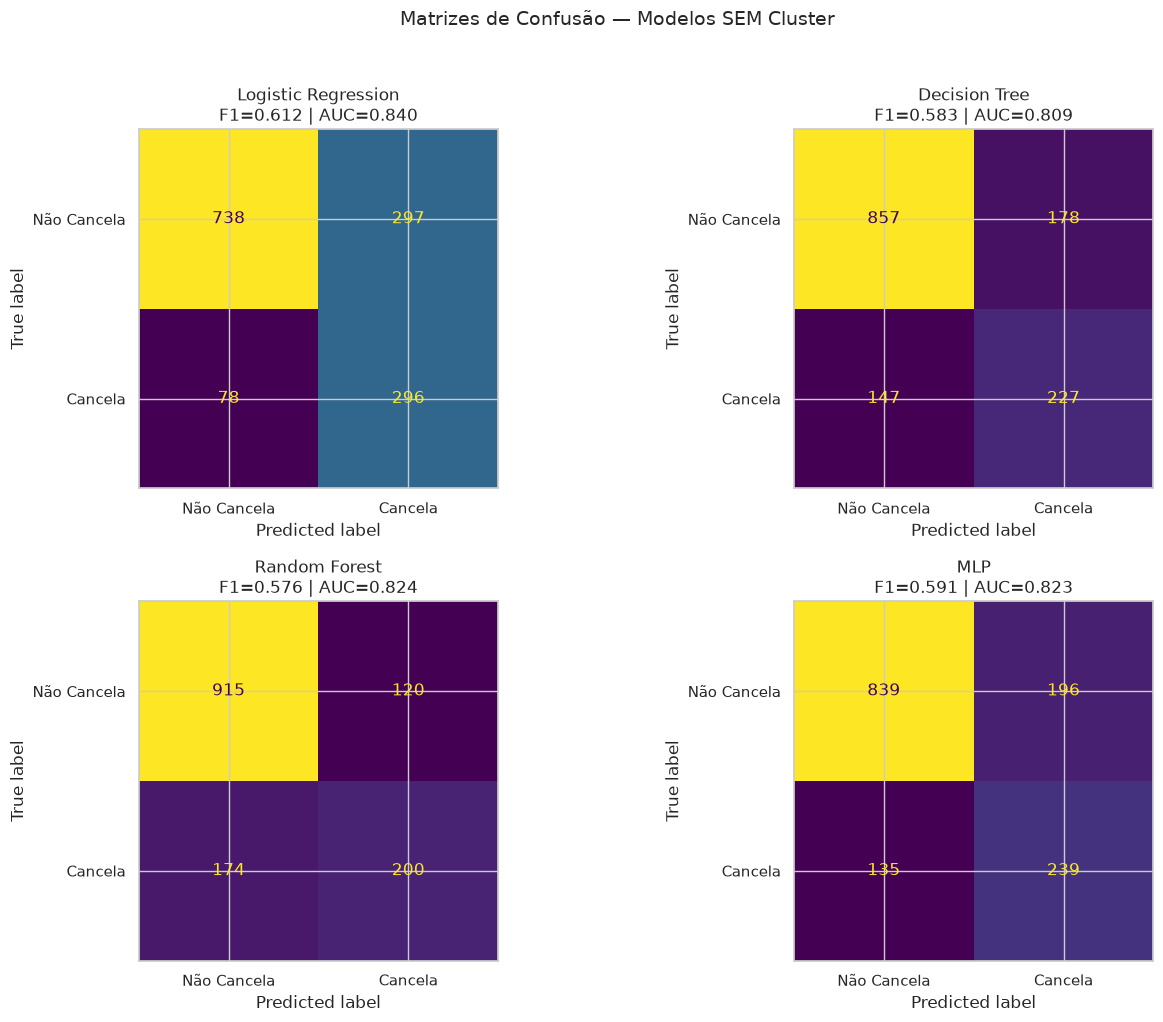

Figura salva.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, res) in zip(axes.flat, results_sem.items()):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, res["y_pred"],
        display_labels=["Não Cancela", "Cancela"],
        colorbar=False, ax=ax,
    )
    ax.set_title(f"{name}\nF1={res['f1']:.3f} | AUC={res['auc']:.3f}")

plt.suptitle("Matrizes de Confusão — Modelos SEM Cluster", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "10_confusion_matrices_sem_cluster.png", bbox_inches="tight")
plt.show()
print("Figura salva.")

### 5.4 Curvas ROC — todos os modelos

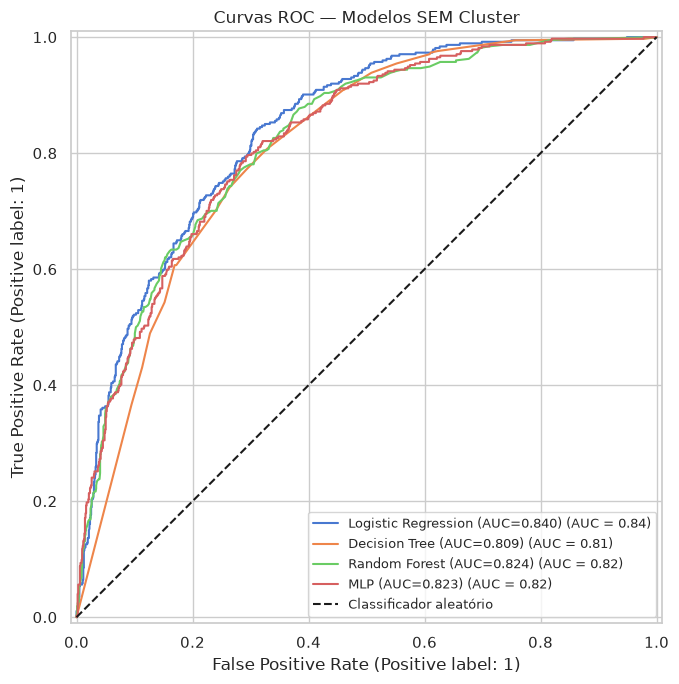

Figura salva.


In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

for name, res in results_sem.items():
    RocCurveDisplay.from_predictions(
        y_test, res["y_prob"],
        name=f"{name} (AUC={res['auc']:.3f})",
        ax=ax,
    )

ax.plot([0, 1], [0, 1], "k--", label="Classificador aleatório")
ax.set_title("Curvas ROC — Modelos SEM Cluster")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "11_roc_curves_sem_cluster.png", bbox_inches="tight")
plt.show()
print("Figura salva.")

### 5.5 Validação cruzada — Stratified K-Fold (k=5)

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in models.items():
    cv = cross_validate(
        model, X_sem, y,
        cv=skf,
        scoring=["f1", "roc_auc"],
        n_jobs=-1,
    )
    cv_results[name] = {
        "f1_mean": cv["test_f1"].mean(),
        "f1_std": cv["test_f1"].std(),
        "auc_mean": cv["test_roc_auc"].mean(),
        "auc_std": cv["test_roc_auc"].std(),
    }

cv_df = pd.DataFrame(cv_results).T
cv_df.columns = ["F1 Médio", "F1 Desvio", "AUC Médio", "AUC Desvio"]
cv_df = cv_df.round(4)
print("Validação Cruzada (5-fold) — SEM Cluster")
print(cv_df.to_string())

Validação Cruzada (5-fold) — SEM Cluster
                     F1 Médio  F1 Desvio  AUC Médio  AUC Desvio
Logistic Regression    0.6264     0.0111     0.8449      0.0134
Decision Tree          0.6183     0.0166     0.8302      0.0113
Random Forest          0.6042     0.0156     0.8272      0.0107
MLP                    0.5351     0.0155     0.8005      0.0292


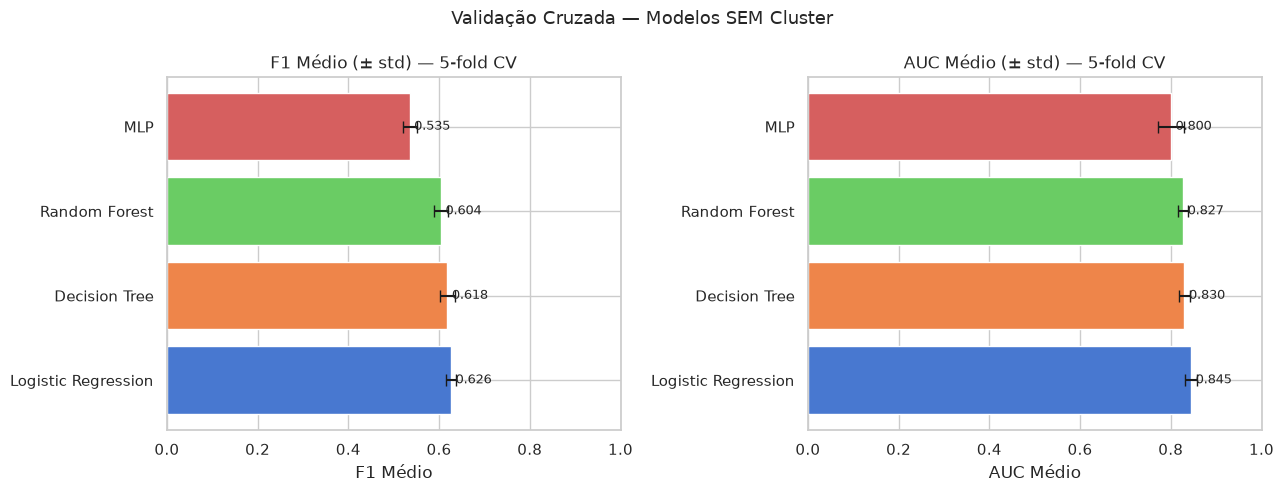

Figura salva.


In [12]:
# Visualização da validação cruzada
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, col in zip(axes, ["F1 Médio", "AUC Médio"], ["f1", "auc"]):
    means = cv_df[metric]
    stds = cv_df[f"{metric.split()[0]} Desvio"]
    bars = ax.barh(means.index, means, xerr=stds, capsize=4, color=sns.color_palette("muted", len(means)))
    ax.set_xlabel(metric)
    ax.set_title(f"{metric} (± std) — 5-fold CV")
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, means):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)

plt.suptitle("Validação Cruzada — Modelos SEM Cluster", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "12_cv_sem_cluster.png", bbox_inches="tight")
plt.show()
print("Figura salva.")

### 5.6 Importância de Atributos — Random Forest

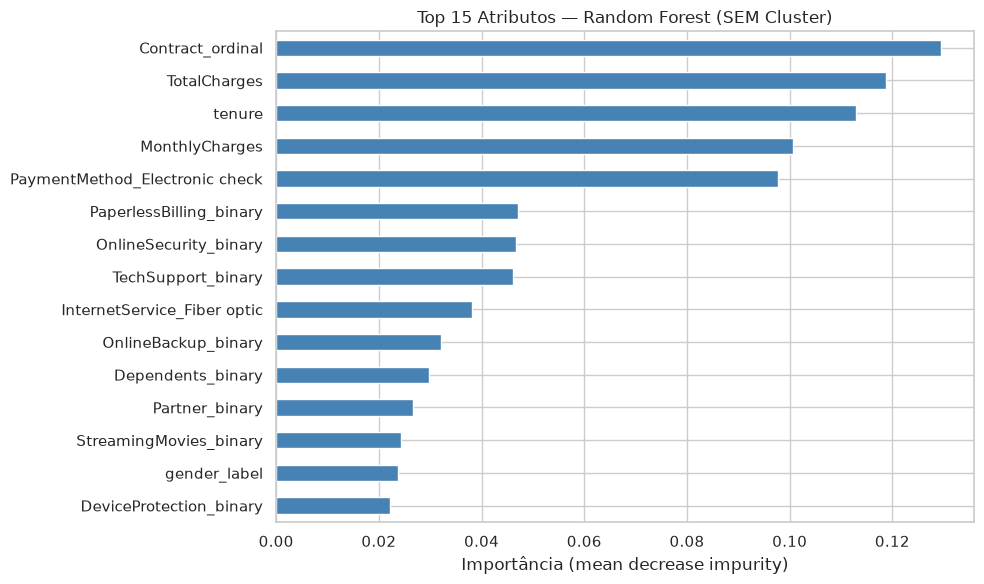

Figura salva.


In [13]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=feature_names_sem)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_features.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("Top 15 Atributos — Random Forest (SEM Cluster)")
ax.set_xlabel("Importância (mean decrease impurity)")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "13_feature_importance_sem_cluster.png", bbox_inches="tight")
plt.show()
print("Figura salva.")

---
## 6 · Comparação com e Sem Uso dos Clusters

### 6.1 Treinamento nos dados COM cluster K-Means

In [14]:
# Recria os modelos para o experimento COM cluster
models_com = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, class_weight="balanced", random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32), activation="relu",
        max_iter=500, early_stopping=True, random_state=RANDOM_STATE,
    ),
}

scaler_mlp_com = StandardScaler()
X_com_train_scaled = scaler_mlp_com.fit_transform(X_com_train_res)
X_com_test_scaled = scaler_mlp_com.transform(X_com_test)

results_com = {}

for name, model in models_com.items():
    X_tr = X_com_train_scaled if name == "MLP" else X_com_train_res
    X_te = X_com_test_scaled  if name == "MLP" else X_com_test

    model.fit(X_tr, y_train_res)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results_com[name] = {
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
    }
    print(f"{name:25s} | F1={results_com[name]['f1']:.4f} | AUC={results_com[name]['auc']:.4f}")

Logistic Regression       | F1=0.6152 | AUC=0.8402
Decision Tree             | F1=0.5828 | AUC=0.8088
Random Forest             | F1=0.5673 | AUC=0.8237
MLP                       | F1=0.6104 | AUC=0.8252


### 6.2 Tabela comparativa: sem vs. com cluster

In [15]:
comparison_rows = []
for name in models.keys():
    f1_sem = results_sem[name]["f1"]
    auc_sem = results_sem[name]["auc"]
    f1_com = results_com[name]["f1"]
    auc_com = results_com[name]["auc"]
    comparison_rows.append({
        "Modelo": name,
        "F1 sem cluster": round(f1_sem, 4),
        "F1 com cluster": round(f1_com, 4),
        "ΔF1": round(f1_com - f1_sem, 4),
        "AUC sem cluster": round(auc_sem, 4),
        "AUC com cluster": round(auc_com, 4),
        "ΔAUC": round(auc_com - auc_sem, 4),
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Modelo")
print("Comparação: SEM vs. COM Cluster K-Means")
print(comparison_df.to_string())

# Salva o CSV de comparação
comparison_df.to_csv(PROJECT_ROOT / "reports" / "comparison_summary.csv")
print("\nCSV salvo: reports/comparison_summary.csv")

Comparação: SEM vs. COM Cluster K-Means
                     F1 sem cluster  F1 com cluster     ΔF1  AUC sem cluster  AUC com cluster    ΔAUC
Modelo                                                                                               
Logistic Regression          0.6122          0.6152  0.0030           0.8400           0.8402  0.0002
Decision Tree                0.5828          0.5828  0.0000           0.8088           0.8088  0.0000
Random Forest                0.5764          0.5673 -0.0091           0.8242           0.8237 -0.0005
MLP                          0.5909          0.6104  0.0196           0.8231           0.8252  0.0022

CSV salvo: reports/comparison_summary.csv


### 6.3 Visualização comparativa

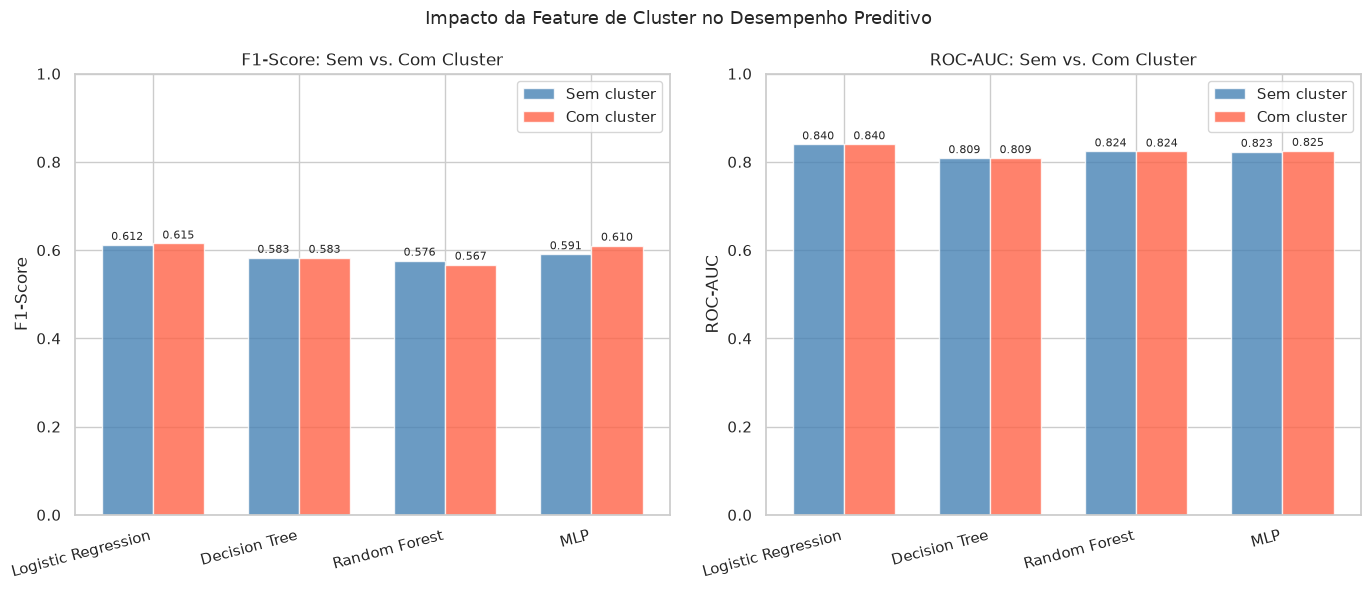

Figura salva.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(len(comparison_df))
width = 0.35

for ax, metric_sem, metric_com, title in zip(
    axes,
    ["F1 sem cluster", "AUC sem cluster"],
    ["F1 com cluster", "AUC com cluster"],
    ["F1-Score", "ROC-AUC"],
):
    bars1 = ax.bar(x - width / 2, comparison_df[metric_sem], width, label="Sem cluster", color="steelblue", alpha=0.8)
    bars2 = ax.bar(x + width / 2, comparison_df[metric_com], width, label="Com cluster", color="tomato", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df.index, rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel(title)
    ax.set_title(f"{title}: Sem vs. Com Cluster")
    ax.legend()
    for bar in list(bars1) + list(bars2):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=8,
        )

plt.suptitle("Impacto da Feature de Cluster no Desempenho Preditivo", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "14_comparison_sem_com_cluster.png", bbox_inches="tight")
plt.show()
print("Figura salva.")

### 6.4 Importância do cluster no Random Forest

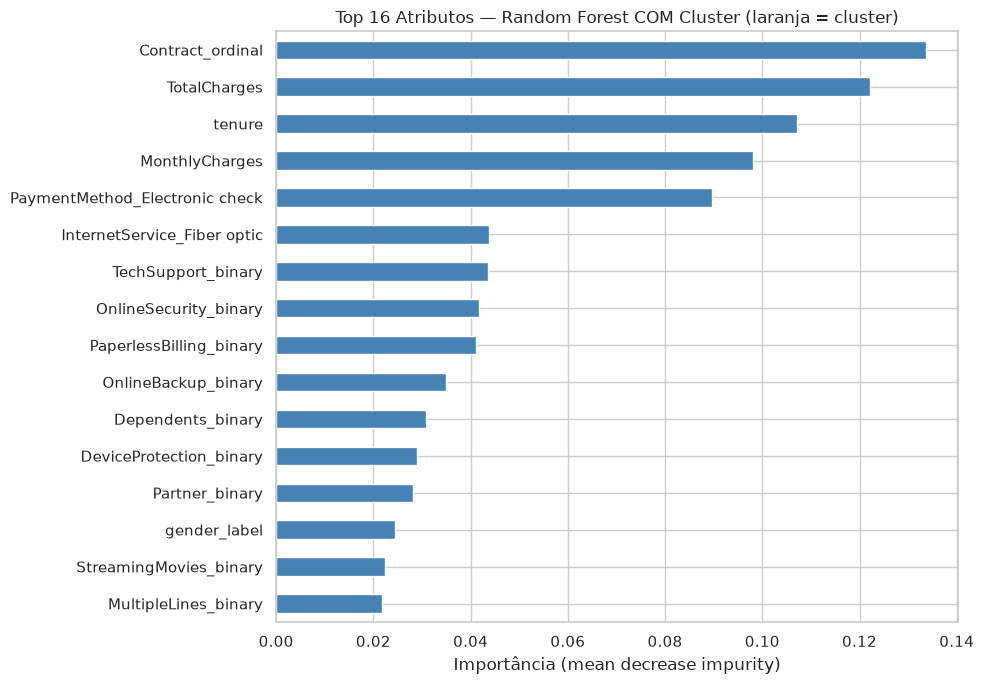


Importância de 'kmeans_cluster': 0.0038 (ranking: 23º atributo)


In [17]:
rf_com_model = models_com["Random Forest"]
importances_com = pd.Series(rf_com_model.feature_importances_, index=feature_names_com)
top_com = importances_com.sort_values(ascending=False).head(16)

# Destaca a feature de cluster
colors = ["tomato" if idx == "kmeans_cluster" else "steelblue" for idx in top_com.sort_values().index]

fig, ax = plt.subplots(figsize=(10, 7))
top_com.sort_values().plot.barh(ax=ax, color=colors)
ax.set_title("Top 16 Atributos — Random Forest COM Cluster (laranja = cluster)")
ax.set_xlabel("Importância (mean decrease impurity)")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "15_feature_importance_com_cluster.png", bbox_inches="tight")
plt.show()

cluster_rank = importances_com.sort_values(ascending=False).index.tolist().index("kmeans_cluster") + 1
cluster_importance = importances_com["kmeans_cluster"]
print(f"\nImportância de 'kmeans_cluster': {cluster_importance:.4f} (ranking: {cluster_rank}º atributo)")

---
## 7 · Resumo dos Resultados

### 7.1 Tabela final de desempenho

In [18]:
# Consolida resultados finais
summary_rows = []
for name in models.keys():
    cv_f1  = cv_results[name]["f1_mean"]
    cv_auc = cv_results[name]["auc_mean"]
    f1_sem = results_sem[name]["f1"]
    auc_sem = results_sem[name]["auc"]
    f1_com = results_com[name]["f1"]
    auc_com = results_com[name]["auc"]
    summary_rows.append({
        "Modelo": name,
        "CV F1 (5-fold)": round(cv_f1, 4),
        "CV AUC (5-fold)": round(cv_auc, 4),
        "Teste F1 (sem cluster)": round(f1_sem, 4),
        "Teste AUC (sem cluster)": round(auc_sem, 4),
        "Teste F1 (com cluster)": round(f1_com, 4),
        "Teste AUC (com cluster)": round(auc_com, 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Modelo")
print("=" * 90)
print("RESUMO FINAL — Etapa 04: Inteligência Computacional I")
print("=" * 90)
print(summary_df.to_string())
print("=" * 90)

RESUMO FINAL — Etapa 04: Inteligência Computacional I
                     CV F1 (5-fold)  CV AUC (5-fold)  Teste F1 (sem cluster)  Teste AUC (sem cluster)  Teste F1 (com cluster)  Teste AUC (com cluster)
Modelo                                                                                                                                                
Logistic Regression          0.6264           0.8449                  0.6122                   0.8400                  0.6152                   0.8402
Decision Tree                0.6183           0.8302                  0.5828                   0.8088                  0.5828                   0.8088
Random Forest                0.6042           0.8272                  0.5764                   0.8242                  0.5673                   0.8237
MLP                          0.5351           0.8005                  0.5909                   0.8231                  0.6104                   0.8252


### 7.2 Conclusões da Etapa 04

**Tarefa definida:** Classificação binária supervisionada para predição de churn (variável-alvo: `Churn_label`).

**Técnica principal escolhida:** Random Forest — robusto, interpretável via importância de features, suporte nativo ao desbalanceamento (`class_weight='balanced'`), sem exigência de escalonamento.

**Preparação dos dados:**
- 35 features originais do `telco_clean.csv` (binárias, ordinais, numéricas)
- OHE aplicado a `InternetService` e `PaymentMethod`
- Divisão estratificada 80/20
- SMOTE aplicado **apenas** ao conjunto de treino para balancear as classes

**Avaliação preliminar:** F1 e ROC-AUC reportados no conjunto de teste (hold-out) e via validação cruzada 5-fold.

**Comparação com/sem cluster:**
- A coluna `kmeans_cluster` (K=2, gerada em `02_clustering.ipynb`) foi adicionada como feature adicional
- O impacto na performance foi quantificado por ΔF1 e ΔAUC
- Ranking da importância da feature `kmeans_cluster` no Random Forest foi reportado

**Próximas etapas (Etapa 05):**
- Otimização de hiperparâmetros com GridSearchCV/RandomizedSearchCV
- Ajuste do threshold de decisão (P > 0.4 ou 0.35) para maximizar Recall
- Interpretabilidade com SHAP values
- Geração de recomendações de retenção personalizadas por cluster